<a href="https://colab.research.google.com/github/tuonglong1012/sgu25-khaiphadulieu/blob/Hieu/Challenge_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **1. Definition**
- This dataset contains information about the passengers of the RMS Titanic, which famously sank in 1912. Each row in the dataset represents a single passenger, and the columns contain various pieces of information about them, such as:
  - **PassengerId:** A unique identifier for each passenger.
  - **Survived:** Whether the passenger survived the sinking (this will be the main target variable to focusing on).
  - **Pclass:** The passenger's ticket class (1st, 2nd and 3rd class).
  - **Name:** The passenger's name.
  - **Sex:** The passenger's gender.
  - **Age:** The passenger's age.
  - **SibSp:** Number of siblings/spouses aboard.
  - **Parch:** Number of parents/children aboard.
  - **Ticket:** Ticket number.
  - **Fare:** The fare paid for the ticket.
  - **Cabin:** The cabin number.
  - **Embarked:** The port where the passenger embarked.
- The utmost reason to analyze this dataset, especially in the context of data science and machine learning, is typically to build a model that can predict whether a passenger survived the sinking based on the information available about them.

## **2. Import libraries**

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **3. Load the dataset**

In [87]:
train_df = pd.read_csv('/content/data/train.csv', index_col="PassengerId")
test_df = pd.read_csv('/content/data/test.csv', index_col="PassengerId")

In [88]:
train_df.columns

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [89]:
test_df.columns

Index(['Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare',
       'Cabin', 'Embarked'],
      dtype='object')

In [90]:
train_df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### **3.1. Features Classification: Categorical and Numerical**
- This will help to decide which plot to use for visualization.
#### **Which are the categorical features?**
- Data that represents groups, labels, or categories.
- Include: `Survived`, `Sex`, `Embarked`, `Pclass`.
#### **Which are the numerical features?**
- Data that represents measurable quantities.
- Include: `Age`, `Fare`, `SibSp`, `Parch`.

<Axes: >

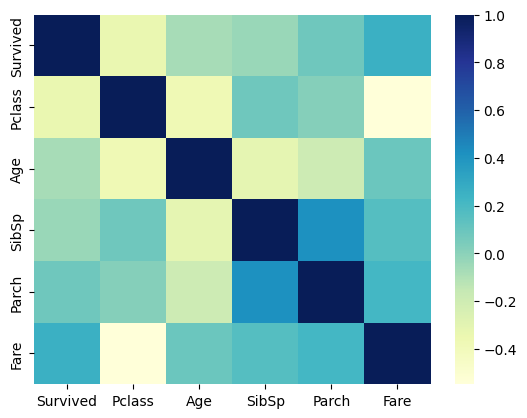

In [91]:
train_df_numerical = train_df.select_dtypes(include=np.number)
sns.heatmap(train_df_numerical.corr(), cmap='YlGnBu')

In [92]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


In [93]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 418 entries, 892 to 1309
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Name      418 non-null    object 
 2   Sex       418 non-null    object 
 3   Age       332 non-null    float64
 4   SibSp     418 non-null    int64  
 5   Parch     418 non-null    int64  
 6   Ticket    418 non-null    object 
 7   Fare      417 non-null    float64
 8   Cabin     91 non-null     object 
 9   Embarked  418 non-null    object 
dtypes: float64(2), int64(3), object(5)
memory usage: 35.9+ KB


In [94]:
features = ["Pclass", "Sex", "SibSp", "Parch", "Embarked"]
def convert_cat(df, features):
  for feature in features:
    df[feature] = df[feature].astype('category')
  return df

train_df = convert_cat(train_df, features)
test_df = convert_cat(test_df, features)

In [95]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Survived  891 non-null    int64   
 1   Pclass    891 non-null    category
 2   Name      891 non-null    object  
 3   Sex       891 non-null    category
 4   Age       714 non-null    float64 
 5   SibSp     891 non-null    category
 6   Parch     891 non-null    category
 7   Ticket    891 non-null    object  
 8   Fare      891 non-null    float64 
 9   Cabin     204 non-null    object  
 10  Embarked  889 non-null    category
dtypes: category(5), float64(2), int64(1), object(3)
memory usage: 54.2+ KB


### **3.1.1. Distribution of Categorical features**

In [96]:
train_df.describe(include='category')

,Pclass,Sex,SibSp,Parch,Embarked
count,891,891,891,891,889
unique,3,2,7,7,3
top,3,male,0,0,S
freq,491,577,608,678,644


### **3.1.2. Distribution of Numerical features**

In [97]:
train_df.describe()

,Survived,Age,Fare
count,891.000000,714.000000,891.000000
mean,0.383838,29.699118,32.204208
std,0.486592,14.526497,49.693429
min,0.000000,0.420000,0.000000
25%,0.000000,20.125000,7.910400
50%,0.000000,28.000000,14.454200
75%,1.000000,38.000000,31.000000
max,1.000000,80.000000,512.329200


## **4. Exploratory Data Analysis (EDA)**
### **4.1. Collerating categorical features**
- Catergorical: `Survived`, `Pclass`, `Sex`, `SibSp`,
       `Parch`, `Embarked`
### **Target variable: `Survived`**

In [98]:
train_df['Survived'].value_counts().to_frame()

,count
Survived,
0,549
1,342


In [99]:
train_df['Survived'].value_counts(normalize=True).to_frame()

,proportion
Survived,
0,0.616162
1,0.383838


Conclude that only 38% of the passengers survived. The data suffered from data imbalanced but not too severe to tackle the imbalance with data sampling.

#### **Sex**

In [100]:
train_df['Sex'].value_counts(normalize=True).to_frame()

,proportion
Sex,
male,0.647587
female,0.352413


<Axes: xlabel='Survived', ylabel='count'>

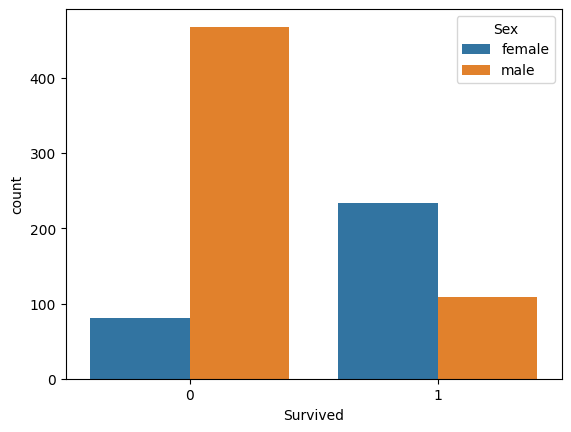

In [101]:
sns.countplot(x='Survived', hue='Sex', data=train_df)

### **Remaining features**

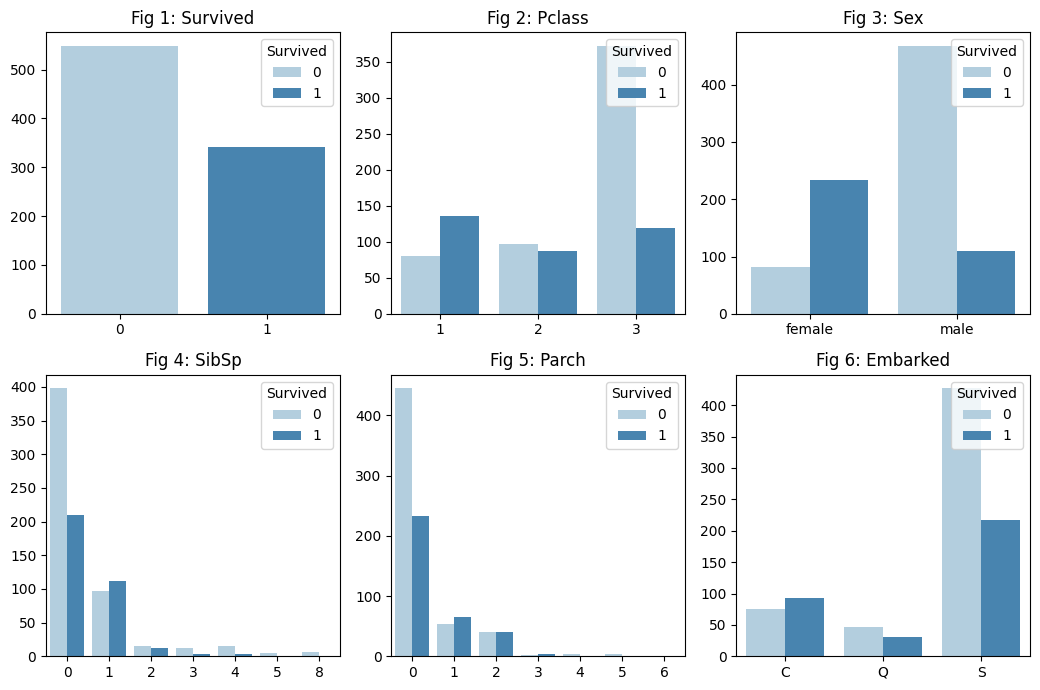

In [102]:
cols = ['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked']

n_rows = 2
n_cols = 3

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*3.5, n_rows*3.5))

for r in range(n_rows):
  for c in range(0, n_cols):
    i = r*n_cols + c
    if i < len(cols):
      ax = axes[r][c]
      sns.countplot(x=cols[i], hue='Survived', data=train_df, ax=ax, palette='Blues')
      ax.set_title(f'Fig {i+1}: {cols[i]}')
      ax.legend(title='Survived', loc='upper right')
      ax.set_xlabel('')
      ax.set_ylabel('')

plt.tight_layout()

#### **Observation:**
- **Survival rate:**
  - Fig 2: Survival rate of the 1st class is the highest.
  - Fig 3: Female had significant higher survival rate than male.  
  - Fig 4 and 5: Passengers who were with 1 or 2 family members had higher chance than going alone.
  - Fig 6: Embarked on Southampton had better chance of surviving but also had the highest rate of not survived.

### **4.2. EDA for Numerical features**
- Numerical features: `Age`, `Fare`.

#### **Age**

In [103]:
train_df['Age'].describe()

,Age
count,714.000000
mean,29.699118
std,14.526497
min,0.420000
25%,20.125000
50%,28.000000
75%,38.000000
max,80.000000


<Axes: xlabel='Age', ylabel='Count'>

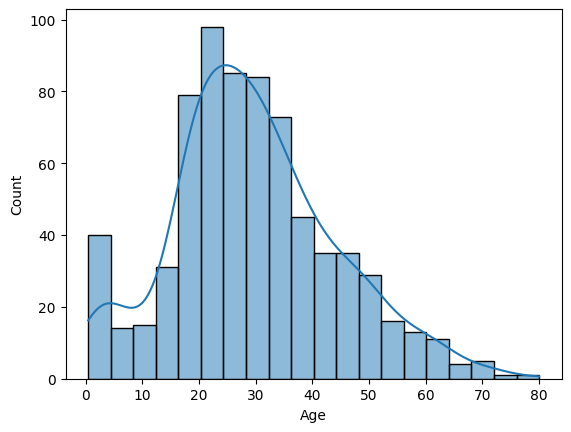

In [104]:
sns.histplot(x='Age', data=train_df, kde=True)

<Axes: xlabel='Age', ylabel='Count'>

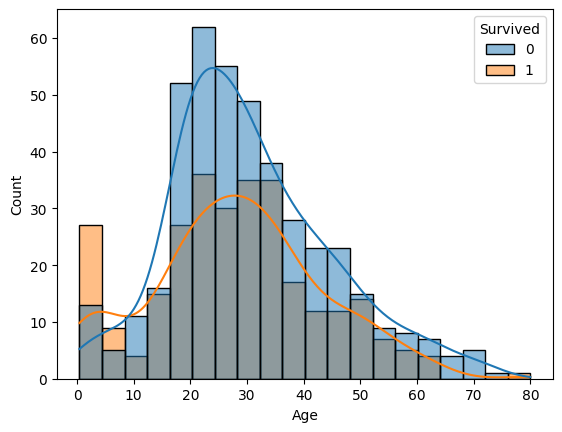

In [105]:
sns.histplot(data=train_df, kde=True, x='Age', hue='Survived')

- The majority of passengers were around 18 to 35 years old.
- Children had higher chance of surviving due to the "women and children first" protocol.

#### **Fare**

In [106]:
train_df['Fare'].describe()

,Fare
count,891.000000
mean,32.204208
std,49.693429
min,0.000000
25%,7.910400
50%,14.454200
75%,31.000000
max,512.329200


<Axes: xlabel='Fare', ylabel='Count'>

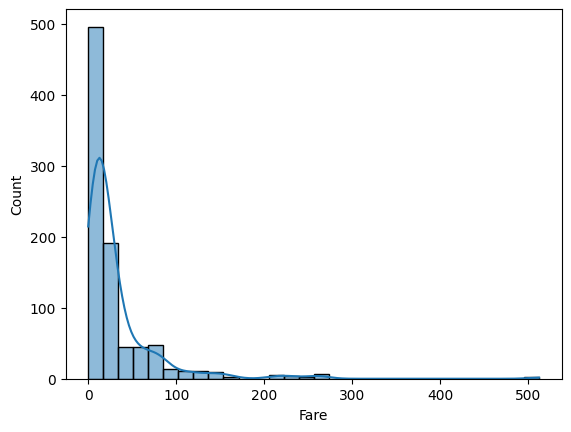

In [107]:
sns.histplot(x='Fare', data=train_df, bins = 30, kde=True)

<Axes: xlabel='Fare', ylabel='Count'>

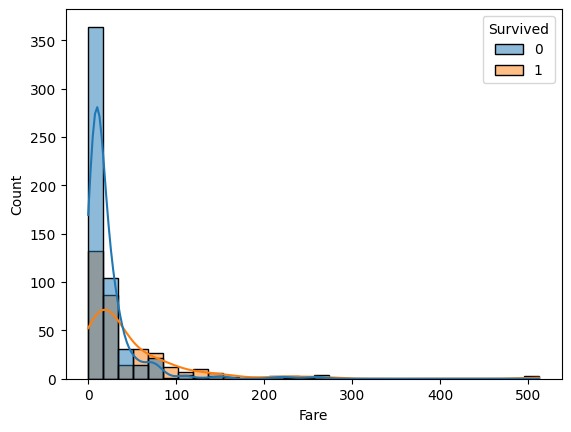

In [108]:
sns.histplot(data=train_df, kde=True, x='Fare', bins = 30, hue='Survived')

In [109]:
pd.qcut(train_df['Fare'], 4)

,Fare
PassengerId,
1,"(-0.001, 7.91]"
2,"(31.0, 512.329]"
3,"(7.91, 14.454]"
4,"(31.0, 512.329]"
5,"(7.91, 14.454]"
...,...
887,"(7.91, 14.454]"
888,"(14.454, 31.0]"
889,"(14.454, 31.0]"


In [110]:
train_df['Fare_Category'] = pd.qcut(train_df['Fare'], 4)
display(train_df[['Fare', 'Fare_Category']].head())

,Fare,Fare_Category
PassengerId,,
1,7.2500,"(-0.001, 7.91]"
2,71.2833,"(31.0, 512.329]"
3,7.9250,"(7.91, 14.454]"
4,53.1000,"(31.0, 512.329]"
5,8.0500,"(7.91, 14.454]"


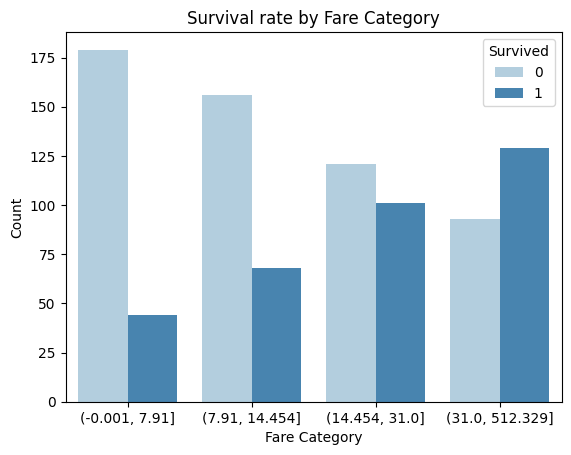

In [111]:
sns.countplot(x='Fare_Category', hue='Survived', data=train_df, palette='Blues')
plt.title('Survival rate by Fare Category')
plt.xlabel('Fare Category')
plt.ylabel('Count')
plt.show()

- Distribution of fare:
  - A large number of passengers paid a lower fare while there are fewer passengers who paid increasingly higher fares. This indicates the fare distribution is skewed.
  - The distribution is skewed to the left side with 75% of the fare paid under `31$` with the max paid of `512$`.
- Relationship with Survival:
  - It became clear that passengers who paid higher fares had more chance of surviving. This suggests a strong positive correlation between the fare paid and the chance of survival.

### **4.3. Handling missing values**

In [112]:
train_df.dropna(subset=['Age'], inplace=True)
test_df.dropna(subset=['Age'], inplace=True)

mode_embarked = train_df['Embarked'].mode()[0]
train_df['Embarked'] = train_df['Embarked'].fillna(mode_embarked)
test_df['Embarked'] = test_df['Embarked'].fillna(mode_embarked)

train_df['Cabin'] = train_df['Cabin'].fillna('Missing')
test_df['Cabin'] = test_df['Cabin'].fillna('Missing')

print("Missing values in Age after handling (Train):", train_df['Age'].isnull().sum())
print("Missing values in Age after handling (Test):", test_df['Age'].isnull().sum())
print("Missing values in Embarked after handling (Train):", train_df['Embarked'].isnull().sum())
print("Missing values in Embarked after handling (Test):", test_df['Embarked'].isnull().sum())
print("Missing values in Cabin after handling (Train):", train_df['Cabin'].isnull().sum())
print("Missing values in Cabin after handling (Test):", test_df['Cabin'].isnull().sum())

Missing values in Age after handling (Train): 0
Missing values in Age after handling (Test): 0
Missing values in Embarked after handling (Train): 0
Missing values in Embarked after handling (Test): 0
Missing values in Cabin after handling (Train): 0
Missing values in Cabin after handling (Test): 0


- **Embarked:** only had 2 missing values. In such case, it's preferable to fill the missing values with reasonable estimate information.
- **Age:** had a significantly large number of missing values (177 in the original training data). Dropping rows will keep the process simple.
- **Cabin:** this column had a very large number of missing values up to 687 (about 77.10%), we would removed a significant portion of the dataset if dropped, which is not ideal for analysis. Instead filling will allow us to keep all the rows and potentially explore.

In [113]:
import joblib

# Lưu hai DataFrame đã xử lý xong
joblib.dump((train_df, test_df), '/content/titanic_after_P1.pkl')

print("✅ Đã lưu toàn bộ dữ liệu sau P1 vào titanic_after_P1.pkl")


✅ Đã lưu toàn bộ dữ liệu sau P1 vào titanic_after_P1.pkl
